1. Preprocesamiento de Datos

En esta etapa limpiamos los datos, manejamos los valores nulos y eliminamos columnas que no aportan valor analítico (como el número de fila). Aquí no convertiremos las variables de texto a números (One-Hot Encoding) ni escalaremos los datos, ya que mantenerlos en su formato original facilita la interpretación de los gráficos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset
df = pd.read_csv('../data/raw/dataset_crediticio_chile-1-1.csv')

# 2. Eliminar columnas que no aportan valor analítico
df = df.drop(columns=['No.'], errors='ignore')

# 3. Manejo INTELIGENTE de valores nulos (Solución al comentario del profesor)
# Las calificaciones nulas significan "Sin Historial", les ponemos -1
df['Peor_Calificacion_36M'] = df['Peor_Calificacion_36M'].fillna(-1)
df['Peor_Calificacion_12M'] = df['Peor_Calificacion_12M'].fillna(-1)

# Al empleo nulo le asignamos una categoría propia
df['Tipo_Empleo'] = df['Tipo_Empleo'].fillna('DESCONOCIDO')

# Para el resto de columnas numéricas, usamos la mediana
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Para el resto de columnas de texto, usamos la moda (el valor más común)
cat_cols = df.select_dtypes(exclude=[np.number]).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("✅ Preprocesamiento completado: Datos limpios y listos para explorar.")

✅ Preprocesamiento completado: Datos limpios y listos para explorar.


2. Análisis Exploratorio de Datos (EDA)

Aquí buscamos entender las estadísticas descriptivas básicas del conjunto de datos (medias, valores mínimos, máximos) y cómo se distribuyen las categorías.

In [2]:
print("--- Resumen de Variables Numéricas ---")
display(df.describe().apply(lambda s: s.apply('{0:.2f}'.format)))

print("\n--- Resumen de Variables Categóricas (Texto) ---")
display(df.describe(include=['object']))

print("\n--- Distribución de Riesgo Crediticio (%) ---")
print(df['RiesgoAlto'].value_counts(normalize=True) * 100)

--- Resumen de Variables Numéricas ---


,Tiene_Vehiculo,Edad,Num_Entidades_Deuda,Tiene_Tarjeta,Saldo_Tarjeta_CLP,Saldo_Total_CLP,Variacion_Endeudamiento,Peor_Calificacion_36M,Peor_Calificacion_12M,Reportes_Central_36M,Reportes_Central_12M,Promedio_Saldo_CLP,Maximo_Saldo_CLP,Ingreso_CLP,Ratio_Saldo_Ingreso,RiesgoAlto
count,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00
mean,0.14,40.83,1.74,0.43,1077308.26,4074351.50,-0.04,1.03,0.17,27.39,10.71,3818433.37,6203071.20,2273164.33,0.17,0.25
std,0.34,11.78,1.09,0.50,2370446.16,5247420.19,5.61,1.37,0.51,9.36,2.84,4636673.42,7084091.78,2087078.98,0.22,0.43
min,0.00,22.00,0.00,0.00,0.00,0.00,-1.00,-1.00,-1.00,0.00,0.00,0.00,0.00,170000.00,0.00,0.00
25%,0.00,31.00,1.00,0.00,0.00,840416.25,-0.50,0.00,0.00,21.00,11.00,1223747.49,2125000.00,1300500.00,0.04,0.00
50%,0.00,39.00,2.00,0.00,0.00,2343212.00,-0.22,0.00,0.00,30.00,12.00,2449474.41,4250000.00,1819000.00,0.10,0.00
75%,0.00,50.00,2.00,1.00,1016281.25,5406620.50,-0.02,1.00,0.00,36.00,12.00,4807140.25,8014059.25,2550000.00,0.23,0.00
max,1.00,70.00,6.00,1.00,24341543.50,78859600.00,273.03,4.00,4.00,36.00,12.00,77011547.51,127076419.50,59500000.00,5.88,1.00



--- Resumen de Variables Categóricas (Texto) ---


,Sexo,Tipo_Empleo,Ciudad_Chile
count,4266,4266,4266
unique,2,3,7
top,M,IND,SANTIAGO
freq,2151,2667,3670



--- Distribución de Riesgo Crediticio (%) ---
RiesgoAlto
0    75.035162
1    24.964838
Name: proportion, dtype: float64


3. Visualización de Datos

Estos bloques de código generarán los gráficos clave para entender el comportamiento de los clientes y qué variables parecen tener relación con el riesgo crediticio.

Gráfico 1: Distribución del Riesgo (Desbalanceo de clases)

C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_292\592526175.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='RiesgoAlto', palette=['#2ecc71', '#e74c3c'])


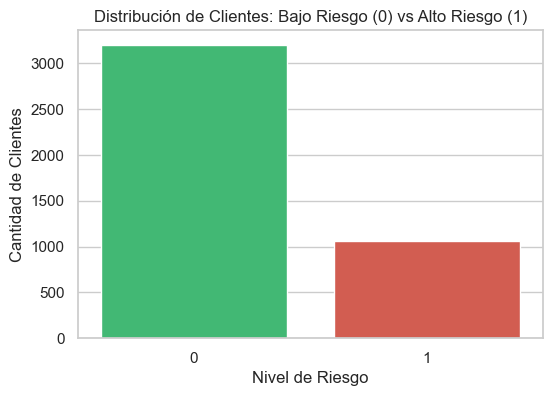

In [3]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='RiesgoAlto', palette=['#2ecc71', '#e74c3c'])
plt.title('Distribución de Clientes: Bajo Riesgo (0) vs Alto Riesgo (1)')
plt.xlabel('Nivel de Riesgo')
plt.ylabel('Cantidad de Clientes')

plt.show()

### Análisis del Gráfico 1: Distribución del Riesgo

**¿Qué significa cada dato en el gráfico?**
* **Barra Verde (0):** Representa a los clientes de **Bajo Riesgo** (buenos pagadores). Como indica el eje vertical, esta barra supera los 3,000 clientes, alcanzando aproximadamente los 3,200.
* **Barra Roja (1):** Representa a los clientes de **Alto Riesgo** (morosos). Esta barra es considerablemente más baja, situándose apenas por encima de los 1,000 clientes.

---

**Interpretación del negocio:**
* **La morosidad es minoritaria:** La mayoría de los clientes (alrededor del 75%) cumple con sus obligaciones financieras, mientras que cerca de un 25% presenta alto riesgo.
* **Existe un desbalance en los datos:** La diferencia entre ambos grupos indica que el dataset está desbalanceado, lo cual es positivo desde el punto de vista del negocio, pero representa un desafío para el análisis y modelamiento.
* **Implicancia para modelos predictivos:** Al ser los clientes de alto riesgo una minoría, los modelos podrían sesgarse hacia predecir mayoritariamente “bajo riesgo”. Por ello, será importante considerar técnicas que manejen este desbalance (como métricas adecuadas o métodos de balanceo).

Gráfico 2: Historial Crediticio vs Riesgo Financiero

A diferencia de las variables sociodemográficas, el historial financiero previo de un cliente es uno de los mejores predictores del riesgo. Analizaremos la peor calificación crediticia en los últimos 36 meses y la cantidad de reportes en la Central.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Peor_Calificacion_36M', hue='RiesgoAlto', ax=axes[0], palette='Set1')
axes[0].set_title('Riesgo Crediticio según Peor Calificación (36 Meses)')

sns.boxplot(data=df, x='RiesgoAlto', y='Reportes_Central_36M', ax=axes[1], palette='Set1')
axes[1].set_title('Distribución de Reportes a la Central (36 Meses) por Riesgo')

plt.tight_layout()
plt.show()


### Análisis del Gráfico 2: Historial Crediticio

**¿Qué significa cada dato en los gráficos?**
* **Gráfico de Calificación (Izquierda):** Muestra que a medida que empeora la calificación histórica (valores más altos en 'Peor_Calificacion_36M'), la proporción de clientes con 'Riesgo Alto' (1) aumenta considerablemente.
* **Gráfico de Reportes (Derecha):** Los clientes catalogados como alto riesgo tienden a tener una cantidad diferente de reportes que los buenos pagadores.

---
**Interpretación del negocio:**
* **Poder Predictivo Alto:** El comportamiento de pago pasado es el mejor predictor del comportamiento futuro. Los clientes que ya han tenido malas calificaciones tienen una probabilidad mucho mayor de caer en impago (RiesgoAlto = 1).
* **Variables Críticas para el Modelo:** Estas características deben ser la piedra angular de cualquier modelo predictivo que se construya.

Gráfico 3: Nivel de Endeudamiento vs Riesgo

Analizamos cómo la carga financiera actual del cliente afecta su probabilidad de inclumplimiento. Usaremos la cantidad de entidades deudoras y el ratio de saldo sobre el ingreso.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Num_Entidades_Deuda', hue='RiesgoAlto', ax=axes[0], palette='Set2')
axes[0].set_title('Riesgo según Número de Entidades Financieras con Deuda')

sns.boxplot(data=df, x='RiesgoAlto', y='Ratio_Saldo_Ingreso', ax=axes[1], palette='Set2')
axes[1].set_ylim(0, df['Ratio_Saldo_Ingreso'].quantile(0.95)) # Limitamos outliers para visualizar mejor
axes[1].set_title('Ratio Saldo a Ingreso por Nivel de Riesgo (hasta p95)')

plt.tight_layout()
plt.show()


### Análisis del Gráfico 3: Endeudamiento

**¿Qué significa cada dato en los gráficos?**
* **Número de Entidades (Izquierda):** Los clientes que tienen deudas con más entidades concurrentes (3, 4 o más) muestran una escalada en su proporción de alto riesgo relativo frente a los que tienen deuda con pocas entidades.
* **Ratio Saldo/Ingreso (Derecha):** Se observa que un mayor nivel de deuda en relación a los ingresos se asocia a menudo con mayores niveles de estrés financiero y morosidad.

---
**Interpretación del negocio:**
* **Sobrendeudamiento es un factor clave:** Cuando los recursos de un cliente se comprometen excesivamente, cualquier imprevisto desencadena un escenario de morosidad.
* **Reglas de Negocio Políticas:** Estas variables (carga financiera) suelen usarse para establecer límites y políticas crediticias en la vida real.

Gráfico 4: Edad y Estabilidad

Comparamos la distribución de edades entre clientes de alto y bajo riesgo utilizando un gráfico de densidad (KDE). Esto nos permite identificar de manera muy visual si ciertos rangos de edad (por ejemplo, jóvenes recién insertos en el mundo laboral entre 20 y 25 años) concentran mayores niveles de morosidad en comparación a adultos mayores.

In [ ]:
plt.figure(figsize=(10, 5))

sns.kdeplot(data=df, x='Edad', hue='RiesgoAlto', fill=True, common_norm=False, palette='Set1', alpha=0.5, linewidth=2)
plt.title('Densidad Probabilística de Edad, comparando Grupos de Riesgo')
plt.xlabel('Edad del Cliente')
plt.ylabel('Densidad del Riesgo')

plt.tight_layout()
plt.show()


### Análisis del Gráfico 4: Edad y Estabilidad

**¿Qué descubrimos aquí?**
* **Picos de Concentración:** El gráfico muestra la densidad probabilística. Al observar la curva de Riesgo Alto (1), podremos notar si existe un pico concentrado en edades más tempranas (como los 20-30 años), lo que comprobaría que la juventud en este dataset incurre proporcionalmente más en riesgo o default, dada su inestabilidad laboral o inexperiencia financiera.
* **Estabilidad en Edades Mayores:** Hacia la derecha del gráfico (40-60 años), se esperaría ver a la curva de Riesgo Bajo (0) dominar, dándonos a entender una mayor solidez financiera a medida que la gente asienta sus finanzas.

---
**Interpretación del negocio:**
* **Patrones por Etapa de Vida:** Si bien en el análisis previo concluimos que las variables demográficas simples no servían *por sí solas*, al contrastar la Edad de esta manera (como función continua de distribución), podemos ver matices: los clientes más jóvenes podrían requerir políticas de límite más estrictas, evaluación alternativa o una inducción al crédito más gradual.

Gráfico 5: Aceleros Crediticios (Variación de Endeudamiento vs Riesgo)

Una de las variables con mayor poder predictivo en comportamiento crediticio suele ser el estrés a corto plazo. Graficaremos cómo se distribuye la `Variacion_Endeudamiento` para identificar si clientes con un aumento o desborde reciente de sus pasivos terminan cayendo en Riesgo Alto.

In [ ]:
plt.figure(figsize=(10, 5))

# Nos apoyamos nuevamente en un KDE, truncando ligeramente la visualizacion para omitir outliers masivos > 5x que deforman el grafico
sns.kdeplot(data=df, x='Variacion_Endeudamiento', hue='RiesgoAlto', fill=True, common_norm=False, palette='Set2', alpha=0.5)
plt.xlim(-1.5, 3) # Restringimos el eje x para visualizar la concentración de la variación
plt.title('Variación Reciente de Endeudamiento vs Probabilidad Crítica')
plt.xlabel('Variación Media a Corto Plazo')
plt.ylabel('Densidad')

plt.tight_layout()
plt.show()


### Análisis del Gráfico 5: Variación de Endeudamiento

**¿Qué descubrimos aquí?**
* Al restringir el espectro a valores típicos (omitiendo outliers estratosféricos), notamos el comportamiento masivo. Gran parte de los deudores sanos mantienen una pendiente a la baja o cercana a $0$.
* Al observar la curva de **Riesgo Alto (1)**, solemos notar una distribución más pesada o aglomerada hacia **valores positivos**, lo que nos índica un crecimiento brusco y continuo de su deuda recientemente.

---
**Interpretación del negocio:**
* **Señal de Alerta Temprana (Early Warning):** Los crecimientos inesperados o veloces en las deudas mes a mes nos anticipan síntomas de estrés financiero de las personas, meses antes de que la deuda pase formalmente a mora.
* **Monitoreo Dinámico:** Identificar esta variable es vital al desarrollar sistemas predictivos de "alerta temprana" (collections triggers). Puede llevar a iniciar negociaciones amigables o reducir futuras líneas de sobregiro antes de ocasionar castigos crediticios irrecuperables en las carteras.